In [1]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import v2
import matplotlib.pyplot as plt
%matplotlib inline

# define training data from fashionMNIST 
training_data = datasets.FashionMNIST(
    root = "data",          # path to the data
    train = True,           # parameter tells if it's used for training or test
    download = True,        # parameter tells if data can get downloaded from internet if necess
    transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale = True)])
)

# define test data (differ from training data) from fashionMNIST
test_data = datasets.FashionMNIST(
    root = "data",
    train = False,
    download = True,
    transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale = True)])
)

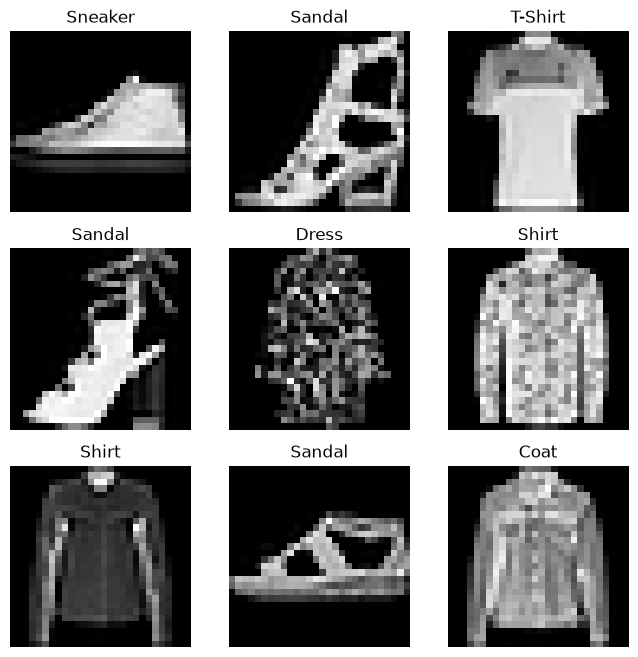

In [7]:
# iterating and visualizing a dataset

labels_map = {      # lookup dictonary
    0: "T-Shirt",
    1: "Trousers",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

figure = plt.figure(figsize = (8,8))
cols, rows = 3, 3           # 3x3 grid
for i in range(1, cols * rows + 1):
    sample_index = torch.randint(len(training_data), size=(1,)).item()    # random number in range of training data and convert to Python number
    img, label = training_data[sample_index]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [ ]:
# create custom data set
import os
import pandas as pd
from torchvision.io import decode_image

class CustomImageDataset(Dataset):          # kind of constructor --> self. will be attribute of the object    
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file) # reads csv and converts to filename & label
        self.img_dir = img_dir                          # takes path to files
        self.transform = transform                      # transform option
        self.target_transform = target_transform        # transform option

    def __len__(self):      # number of examples / training data
        return len(self.img_labels)    

    def __getitem__(self, idx):   # loads & returns sample from dataset at the index
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0]) # create path
        image = decode_image(img_path)          # loads file and converts to tensor
        label = self.img_labels.iloc[idx, 1]    # gets matching label
        if self.transform:                      
            image = self.transform(image)
        if self.target_transform:               
            label = self.target_transform(label)
        return image, label

In [8]:
# preparing data for training with DataLoaders
    # want to train in minibatches (groups of examples)
    # want to reshuffle training data after every epoche (reshuffle test data not necessary)
    # want to do multiprocessing if possible

from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)    # shuffle not necessary

feature batch shape: torch.Size([64, 1, 28, 28])
labels batch shape: torch.Size([64])


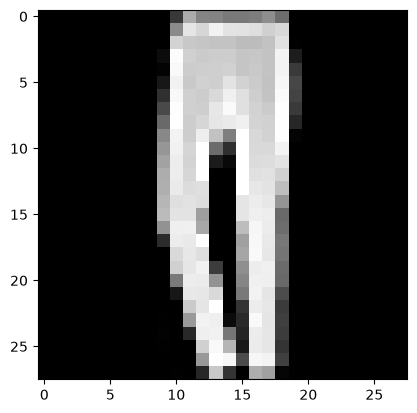

label: 1


In [11]:
# iterate through DataLoader

# display image and label
train_features, train_labels = next(iter(train_dataloader))     # converting to iterable and iterate

# display shapes
print(f"feature batch shape: {train_features.size()}")  
print(f"labels batch shape: {train_labels.size()}")

# display first image
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"label: {label}")